# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

In [23]:
from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor

# Simulating data

## Single df

### Creating

In [2]:
gdf_output = return_spatial_geo_df3(n_x = 40,  
    n_y = 20,    
    spacing = 100, 

    treated_scope_x_start = 10,
    treated_scope_x_end = 24,
    treated_scope_y_start = 7,
    treated_scope_y_end = 13,

    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 25,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 11,

    rho = 0.15,

    spatial_confounder_scope_x_start = 12,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 2,
    spatial_confounder_scope_y_end = 18,

    lambda_cs = 0.2,
    max_treatment_spillover_distance = 400,
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

#### Numerical checks

In [3]:
gdf_output[gdf_output['spill']!=0]

,unit_id,geometry,x,y,T,propensity,T_tot,C1,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
127,1127,POINT (600 700),600,700,0,0.525764,1,-0.786167,1.049242,1.425520,0.284287,0.006983,1.043376,0.006693,400.0,0.006693,0.588447,0.648675
128,1128,POINT (600 800),600,800,0,0.338553,1,1.127944,-0.682435,-0.717428,0.133635,0.009995,1.493385,0.006693,400.0,0.006693,0.029348,0.000943
129,1129,POINT (600 900),600,900,0,-1.273224,1,-0.645050,-0.318096,-0.200617,-0.063186,0.002906,0.434185,0.006693,400.0,0.006693,-0.389131,-0.551161
130,1130,POINT (600 1000),600,1000,0,1.466316,1,0.728834,1.048313,0.025861,0.475839,0.008484,1.267593,0.006693,400.0,0.006693,1.111223,1.120611
131,1131,POINT (600 1100),600,1100,0,0.344563,1,2.436565,-0.063432,-0.947602,-0.844066,0.010949,1.635877,0.006693,400.0,0.006693,0.857158,0.783348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,1569,POINT (2800 900),2800,900,0,1.742258,1,-0.347305,0.408882,-0.646553,2.806971,0.005981,0.893608,0.006693,400.0,0.006693,1.998315,1.998315
570,1570,POINT (2800 1000),2800,1000,0,-0.092262,1,0.370388,1.881085,-1.882726,-0.631485,0.010100,1.509033,0.006693,400.0,0.006693,0.184807,0.184807
571,1571,POINT (2800 1100),2800,1100,0,-1.249222,1,0.275023,-0.376674,-0.620988,-0.804631,0.006371,0.951934,0.006693,400.0,0.006693,-1.128845,-1.128845
572,1572,POINT (2800 1200),2800,1200,0,0.700400,1,0.430889,1.640793,-0.841301,-0.607934,0.009978,1.490822,0.006693,400.0,0.006693,0.596765,0.596765


In [4]:
gdf_output['spill'].unique()

array([0.        , 0.00669285, 0.01774272, 0.0518728 , 0.07585818,
       0.11194084, 0.35659586, 0.5       , 0.8122148 , 0.92414182,
       1.        ])

In [5]:
gdf_output[(gdf_output['T_tot']!=0)
            #&(gdf_output2['T']!=0)
            ]['tau'].mean()

np.float64(0.7434118477576563)

In [6]:
gdf_output[(gdf_output['T_tot']!=0)
            &(gdf_output['T']!=0)
            ]['tau'].mean()

np.float64(1.5)

In [7]:
gdf_output[gdf_output['T']==1]

,unit_id,geometry,x,y,T,propensity,T_tot,C1,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
207,1207,POINT (1000 700),1000,700,1,-0.322996,1,-1.613076,-0.682074,1.965904,-1.303290,0.921587,0.921587,1.0,0.0,1.0,0.392675,0.226559
208,1208,POINT (1000 800),1000,800,1,1.206433,1,-0.880128,2.036655,1.026971,-0.933408,1.670098,1.670098,1.0,0.0,1.0,1.999023,1.811486
209,1209,POINT (1000 900),1000,900,1,-0.590264,1,-0.672023,0.611865,-0.843946,0.890231,1.406003,1.406003,1.0,0.0,1.0,2.201657,1.888341
210,1210,POINT (1000 1000),1000,1000,1,0.851610,1,0.079226,0.429654,-0.469018,0.870849,1.442502,1.442502,1.0,0.0,1.0,2.180513,2.092367
211,1211,POINT (1000 1100),1000,1100,1,-2.786039,1,0.010374,-0.482398,0.532619,-2.072322,1.760388,1.760388,1.0,0.0,1.0,0.646594,0.463108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,1489,POINT (2400 900),2400,900,1,0.842069,1,-1.150336,0.211357,-0.196601,0.329120,1.124606,1.124606,1.0,0.0,1.0,1.037154,0.660044
490,1490,POINT (2400 1000),2400,1000,1,0.712887,1,-0.617169,0.382954,0.378286,1.604448,1.265268,1.265268,1.0,0.0,1.0,2.843574,2.506621
491,1491,POINT (2400 1100),2400,1100,1,0.673711,1,0.395299,1.048138,0.378273,0.413655,2.282893,2.282893,1.0,0.0,1.0,4.037984,3.669522
492,1492,POINT (2400 1200),2400,1200,1,1.814276,1,1.508458,0.557885,0.056382,0.820790,2.282707,2.282707,1.0,0.0,1.0,4.117291,4.117291


In [8]:
gdf_output.isna().any().any()

np.False_

In [9]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 
moran_I_y= Moran(gdf_output['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.2026', 'p-value simulated: 0.0010']

#### Visual checks

In [10]:
gdf_output3 = gdf_output.copy()
gdf_output3['spill2'] = gdf_output3['spill'] + 0.5

<Axes: >

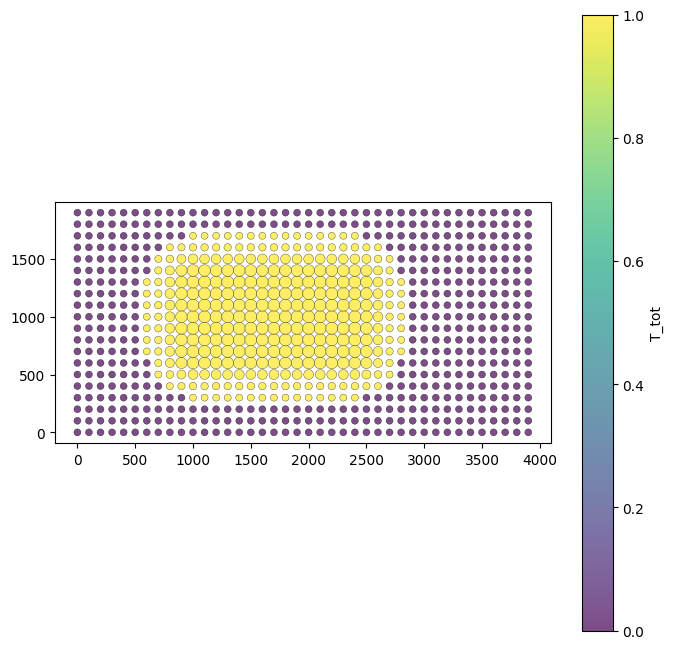

In [11]:
plot_gdf_points(gdf_output3, size_col='spill2',
    color_col='T_tot')

<Axes: >

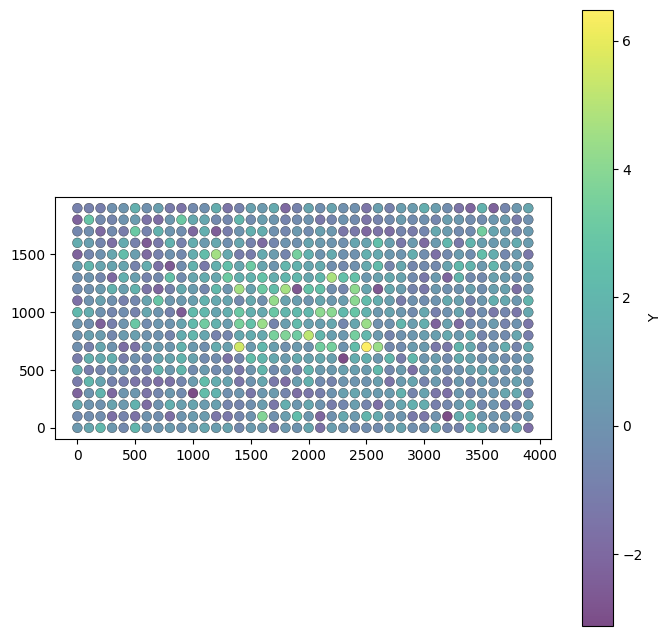

In [12]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y')

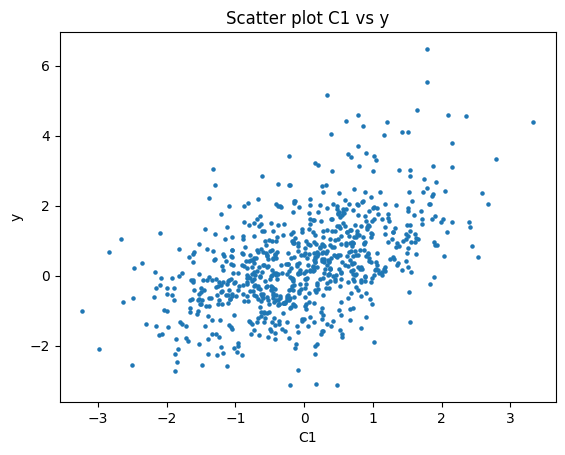

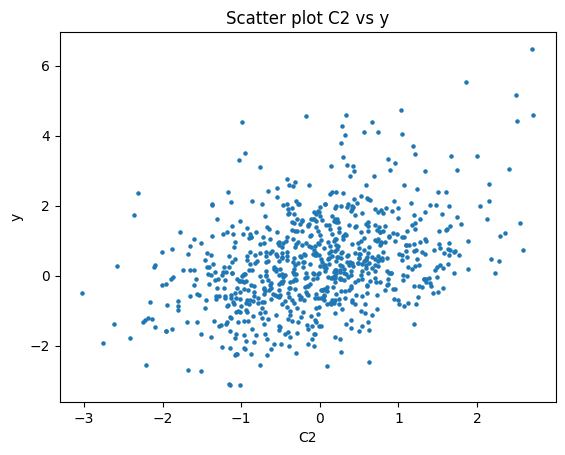

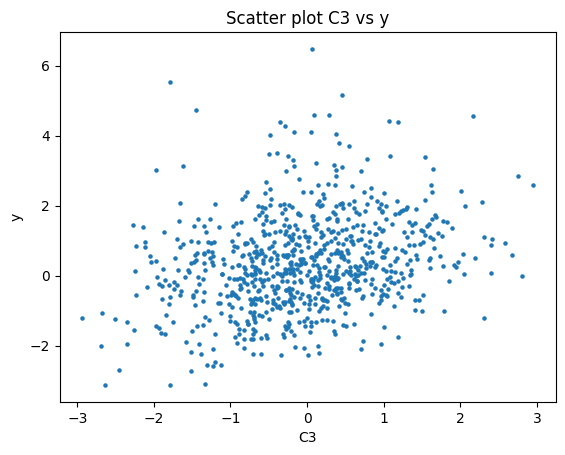

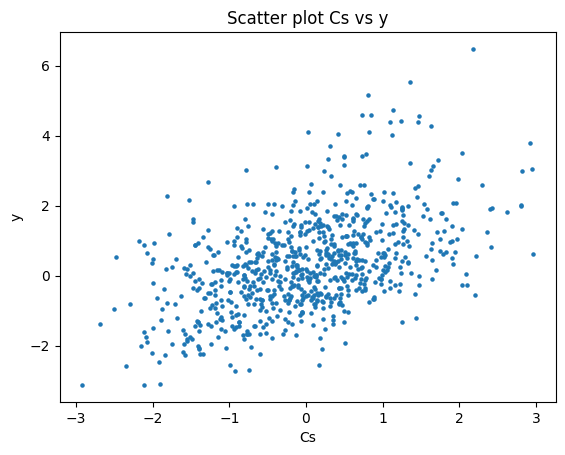

In [13]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [14]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y"].values.reshape(-1,1)
T = gdf_output["T"].values
T_tot = gdf_output["T_tot"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
Xdf2 = gdf_output[["C1","C2",'T_tot',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
y_l = gdf_output["Y_ns"]
Y = gdf_output['Y'].values

X_logit = sm.add_constant(X)

##### Logit for T

In [15]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.388116
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Sun, 10 May 2026   Pseudo R-squ.:                0.001646
Time:                        19:39:59   Log-Likelihood:                -310.49
converged:                       True   LL-Null:                       -311.00
Covariance Type:            nonrobust   LLR p-value:                    0.5993
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8955      0.105    -17.989      0.000      -2.102      -1.689
x1            -0.0957      0.

##### Cross sectional linear difference in differences 

In [16]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.559
Method:                 Least Squares   F-statistic:                     338.9
Date:                Sun, 10 May 2026   Prob (F-statistic):          9.49e-142
Time:                        19:39:59   Log-Likelihood:                -1024.0
No. Observations:                 800   AIC:                             2056.
Df Residuals:                     796   BIC:                             2075.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1966      0.033      5.931      0.0

In [17]:
model = sm.OLS(y_l, X_l2)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     254.8
Date:                Sun, 10 May 2026   Prob (F-statistic):          7.40e-116
Time:                        19:39:59   Log-Likelihood:                -1084.0
No. Observations:                 800   AIC:                             2176.
Df Residuals:                     796   BIC:                             2195.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1195      0.043      2.797      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [18]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           Y                Number of Observations:         800
Mean dependent var  :      0.3647                Number of Variables   :           8
S.D. dependent var  :      1.3419                Degrees of Freedom    :         792
Pseudo R-squared    :      0.5848
Spatial Pseudo R-squared:  0.5758
Log likelihood      :  -1021.3407
Sigma-square ML     :      0.7468                Akaike info criterion :    2058.681
S.E of regression   :      0.8642                Schwarz criterion     :    2096.158

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----

##### Basic causal forest

###### For T

In [96]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

,unit_id,geometry,T,tau,tau_cf
207,1207,POINT (1000 700),1,0.921587,0.795765
208,1208,POINT (1000 800),1,1.670098,1.790925
209,1209,POINT (1000 900),1,1.406003,2.062195
210,1210,POINT (1000 1000),1,1.442502,1.870333
211,1211,POINT (1000 1100),1,1.760388,1.766116
...,...,...,...,...,...
489,1489,POINT (2400 900),1,1.124606,1.518104
490,1490,POINT (2400 1000),1,1.265268,2.151972
491,1491,POINT (2400 1100),1,2.282893,2.311672
492,1492,POINT (2400 1200),1,2.282707,2.535930


In [20]:
ci_low_ate, ate, ci_high_ate

(np.float64(1.626733031574374),
 np.float64(1.655105691546735),
 np.float64(1.683478351519096))

In [21]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

np.float64(1.655450962630058)

###### For T tot

In [22]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T_tot)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T_tot, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T_tot', 'tau', 'tau_base']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T_tot']==1]

,unit_id,geometry,T_tot,tau,tau_base,tau_cf
127,1127,POINT (600 700),1,0.006983,1.043376,1.032315
128,1128,POINT (600 800),1,0.009995,1.493385,0.740112
129,1129,POINT (600 900),1,0.002906,0.434185,0.924621
130,1130,POINT (600 1000),1,0.008484,1.267593,1.211374
131,1131,POINT (600 1100),1,0.010949,1.635877,1.025602
...,...,...,...,...,...,...
569,1569,POINT (2800 900),1,0.005981,0.893608,1.293270
570,1570,POINT (2800 1000),1,0.010100,1.509033,0.906567
571,1571,POINT (2800 1100),1,0.006371,0.951934,0.581843
572,1572,POINT (2800 1200),1,0.009978,1.490822,0.914971


#### S learner with multiple treatments

In [24]:
X

array([[-0.59381835,  0.05950228],
       [-1.086498  , -0.91039133],
       [ 2.0741034 , -1.77736089],
       ...,
       [-0.73025898,  0.49107685],
       [-1.61046236,  0.30959887],
       [ 0.44595684,  0.70731131]], shape=(800, 2))

In [35]:
gdf_output4 = gdf_output.copy()

In [36]:
gdf_output4[gdf_output4['spill'] != 0]['spill'].value_counts()

spill
1.000000    105
0.006693     44
0.500000     44
0.075858     44
0.924142     44
0.017743      8
0.051873      8
0.356596      8
0.111941      4
0.812215      4
Name: count, dtype: int64

In [ ]:
gdf_output4['treated'] = 'control'

Series([], Name: treated, dtype: object)

In [76]:
gdf_output4['treated'] = 'control'
gdf_output4.loc[(gdf_output4['spill'] == 1),'treated'] = 'inner_ring'
gdf_output4.loc[(gdf_output4['spill'] <= 0.924143)& (gdf_output4['spill'] >= 0.812214),'treated'] = 'outer_ring1'
gdf_output4.loc[(gdf_output4['spill'] <= 0.500001)& (gdf_output4['spill'] >= 0.356595),'treated'] = 'outer_ring2'
gdf_output4.loc[(gdf_output4['spill'] <= 0.111942)& (gdf_output4['spill'] >= 0.075857),'treated'] = 'outer_ring3'
gdf_output4.loc[(gdf_output4['spill'] <= 0.017744)& (gdf_output4['spill'] >= 0.006692),'treated'] = 'outer_ring4'


In [77]:
T_M= gdf_output4['treated'].values
T_M= T_M.astype(str)

In [92]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate, lb, ub = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df = pd.DataFrame(ite).rename(columns = {0:'inner_ring', 1:'outer_ring1', 
                                             2:'outer_ring2', 3:'outer_ring3',
                                             4:'outer_ring4'})
ITE_df['treated'] = T_M
ITE_df['ITE_real'] = gdf_output4['tau']
ITE_df['Y'] = Y

In [80]:
ITE_df['treated'].unique()

array(['control', 'outer_ring4', 'outer_ring3', 'outer_ring2',
       'outer_ring1', 'inner_ring'], dtype=object)

In [94]:
for i in ['outer_ring4', 'outer_ring3', 'outer_ring2', 'outer_ring1', 'inner_ring']:
    print(i, 
          ITE_df[ITE_df['treated']==i][i].mean(), 
          ITE_df[ITE_df['treated']==i]['ITE_real'].mean())

outer_ring4 0.012630441717630612 0.008114657327314602
outer_ring3 0.029283273724672123 0.07818203602463208
outer_ring2 0.23283834871213507 0.47835634593117604
outer_ring1 0.4904666803970486 0.9538882329843575
inner_ring 1.702591127291937 1.5


In [86]:
ITE_df

,inner_ring,outer_ring1,outer_ring2,outer_ring3,inner_ring4,treated,ITE_real,Y
0,1.734286,1.074604,0.137102,0.019957,0.327945,control,0.0,0.294466
1,1.368234,-0.089197,-0.039560,-0.040706,-0.030827,control,0.0,-0.394890
2,-0.004964,0.143708,0.150551,-0.204795,0.029387,control,0.0,1.255335
3,2.659240,0.885652,0.267075,-0.009963,0.395581,control,0.0,-2.189175
4,2.170573,-0.130105,0.022143,0.017552,0.082529,control,0.0,-1.154230
...,...,...,...,...,...,...,...,...
795,0.967318,0.125169,0.198429,0.128340,-0.368025,control,0.0,-1.330821
796,1.199752,0.813188,0.162814,-0.037041,-0.323360,control,0.0,0.562769
797,2.252727,0.572463,0.077826,-0.009202,0.379611,control,0.0,0.375063
798,0.917457,0.306563,0.077058,0.006929,0.042576,control,0.0,-0.135151


In [87]:
ITE_df[ITE_df['treated']=='inner_ring']['ITE_real'].mean()

np.float64(1.5)

## Generating multiple df for simulations

### Data generation

In [ ]:
list_of_rhos = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
dict_of_output_gdf = {}
for i in list_of_rhos:
    single_gdf_output = return_spatial_geo_df(n_x = 40,  
        n_y = 20,    
        spacing = 100, 
        treated_scope_x_start = 10,
        treated_scope_x_end = 24,
        treated_scope_y_start = 7,
        treated_scope_y_end = 13,
        ATT_target = 1.5,
        y_spatial_autocorelation_scope_x_start = 3,
        y_spatial_autocorelation_scope_x_end = 25,
        y_spatial_autocorelation_scope_y_start = 4,
        y_spatial_autocorelation_scope_y_end = 11,
        rho = i,
        spatial_confounder_scope_x_start = 12,
        spatial_confounder_scope_x_end = 32,
        spatial_confounder_scope_y_start = 2,
        spatial_confounder_scope_y_end = 18,
        lambda_cs = 0.2,
        distance_ring_number = 2,
        distance_ring_ate_scalars=[0.4, 0.15],
        nonspatial_confounders_contribution_to_Y=1.0,
        spatial_confounder_contribution_to_Y=0.7,
        epsilon_distribution_mean = 0.025,
        epsilon_distribution_standard_error = 0.2)
    single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
    dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:]}'] = single_gdf_output2

In [ ]:
dict_of_output_gdf.keys()

In [ ]:
moran_I_y= Moran(dict_of_output_gdf['gdf_rho_0_55']['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

### Data saving

In [ ]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

In [ ]:
conn = sqlite3.connect(repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite')
cursor = conn.cursor()

In [ ]:
repo_path_r_string

In [ ]:
for k in dict_of_output_gdf.keys():
    dict_of_output_gdf[k].to_file(
        repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite',
        layer=k,
        driver="SQLite",
        #spatialite=True,
        #if_exists="replace"
    )